In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "results")
os.makedirs(OUTPUT_DIR, exist_ok=True)

gas = pd.read_csv("../building_data/gas_cleaned.csv")
electricity = pd.read_csv("../building_data/electricity_cleaned.csv")
weather = pd.read_csv("../building_data/weather.csv")
meta = pd.read_csv("../building_data/metadata.csv")


In [18]:
# Panther building columns
panther_cols_gas = [c for c in gas.columns if c.startswith("Panther_")]
gas_p = gas[["timestamp"] + panther_cols_gas].set_index("timestamp")
panther_cols_elec = [c for c in electricity.columns if c.startswith("Panther_")]
elec_p = electricity[["timestamp"] + panther_cols_elec].set_index("timestamp")

# Weather for Panther site
drop = ["precipDepth6HR", "cloudCoverage", "site_id"]
weather_p = (weather[weather.site_id == "Panther"].drop(columns=[c for c in drop if c in weather.columns]).set_index("timestamp"))

In [19]:
# Aggregating
demand = gas_p.sum(axis=1, min_count=1)
demand.name = "energy_demand"

In [20]:
# Master dataframe
df = pd.DataFrame({"energy_demand": demand}).join(weather_p)
df["energy_demand"] = df["energy_demand"].interpolate().ffill().bfill()
for col in weather_p.columns:
    df[col] = df[col].interpolate().ffill().bfill()

In [21]:
# Calendar features
df.index = pd.to_datetime(df.index)

df["year"]      = df.index.year
df["month"]     = df.index.month
df["dayofweek"] = df.index.dayofweek       
df["hour"]      = df.index.hour
df["date"]      = df.index.normalize()
df["week"]      = df.index.isocalendar().week.astype(int)
df["is_weekend"]= (df["dayofweek"] >= 5).astype(int)
MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
DOW_NAMES   = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

In [22]:
#Figure 1: Summary Statistics
fig1 = plt.figure(figsize=(36, 28))
vals = df["energy_demand"].values

ss = fig1.add_subplot()
ss.axis("off")
stats = {
    "Metric": ["Count", "Mean (kWh)", "Median (kWh)", "Std Dev",
               "Min", "Max", "25th pct", "75th pct",
               "IQR", "CV (%)"],
    "Value": [
        f"{len(df):,}",
        f"{vals.mean():,.1f}",
        f"{np.median(vals):,.1f}",
        f"{vals.std():,.1f}",
        f"{vals.min():,.1f}",
        f"{vals.max():,.1f}",
        f"{np.percentile(vals,25):,.1f}",
        f"{np.percentile(vals,75):,.1f}",
        f"{np.percentile(vals,75)-np.percentile(vals,25):,.1f}",
        f"{vals.std()/vals.mean()*100:.1f}",
    ]
}
table = ss.table(
    cellText=[[a, b] for a, b in zip(stats["Metric"], stats["Value"])],
    colLabels=["Statistic", "Value"],
    loc="center", cellLoc="center"
)
table.scale(5, 30)
table.set_fontsize(100)
ss.set_title("Summary Statistics - Energy Demand")


Text(0.5, 1.0, 'Summary Statistics - Energy Demand')

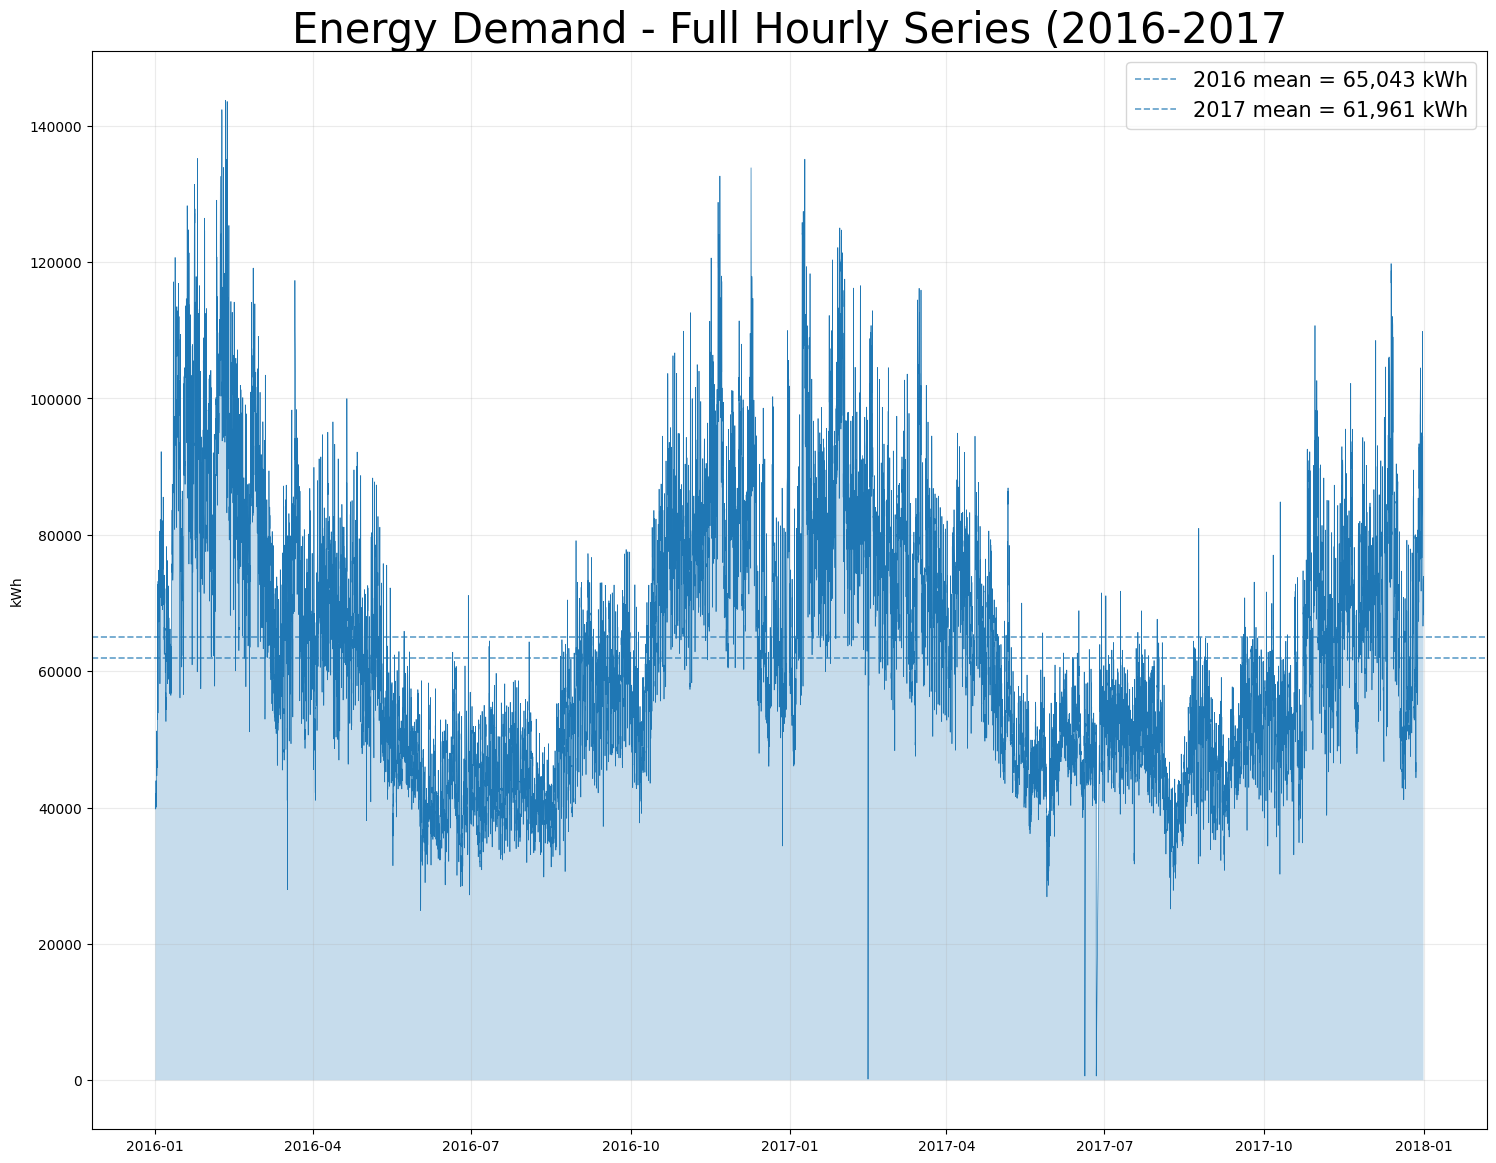

In [23]:
#Figure 2: Overview
fig2 = plt.figure(figsize=(18, 14))

ts = fig2.add_subplot()
ts.fill_between(df.index, df["energy_demand"], alpha=0.25)
ts.plot(df.index, df["energy_demand"], lw=0.5)
for yr, grp in df.groupby("year"):
    mu = grp["energy_demand"].mean()
    ts.axhline(mu, lw=1.2, ls="--", alpha=0.7, label=f"{yr} mean = {mu:,.0f} kWh")

ts.set_title("Energy Demand - Full Hourly Series (2016-2017", fontsize=30)
ts.set_ylabel("kWh")
ts.legend(fontsize=15); ts.grid(True, alpha=0.25)





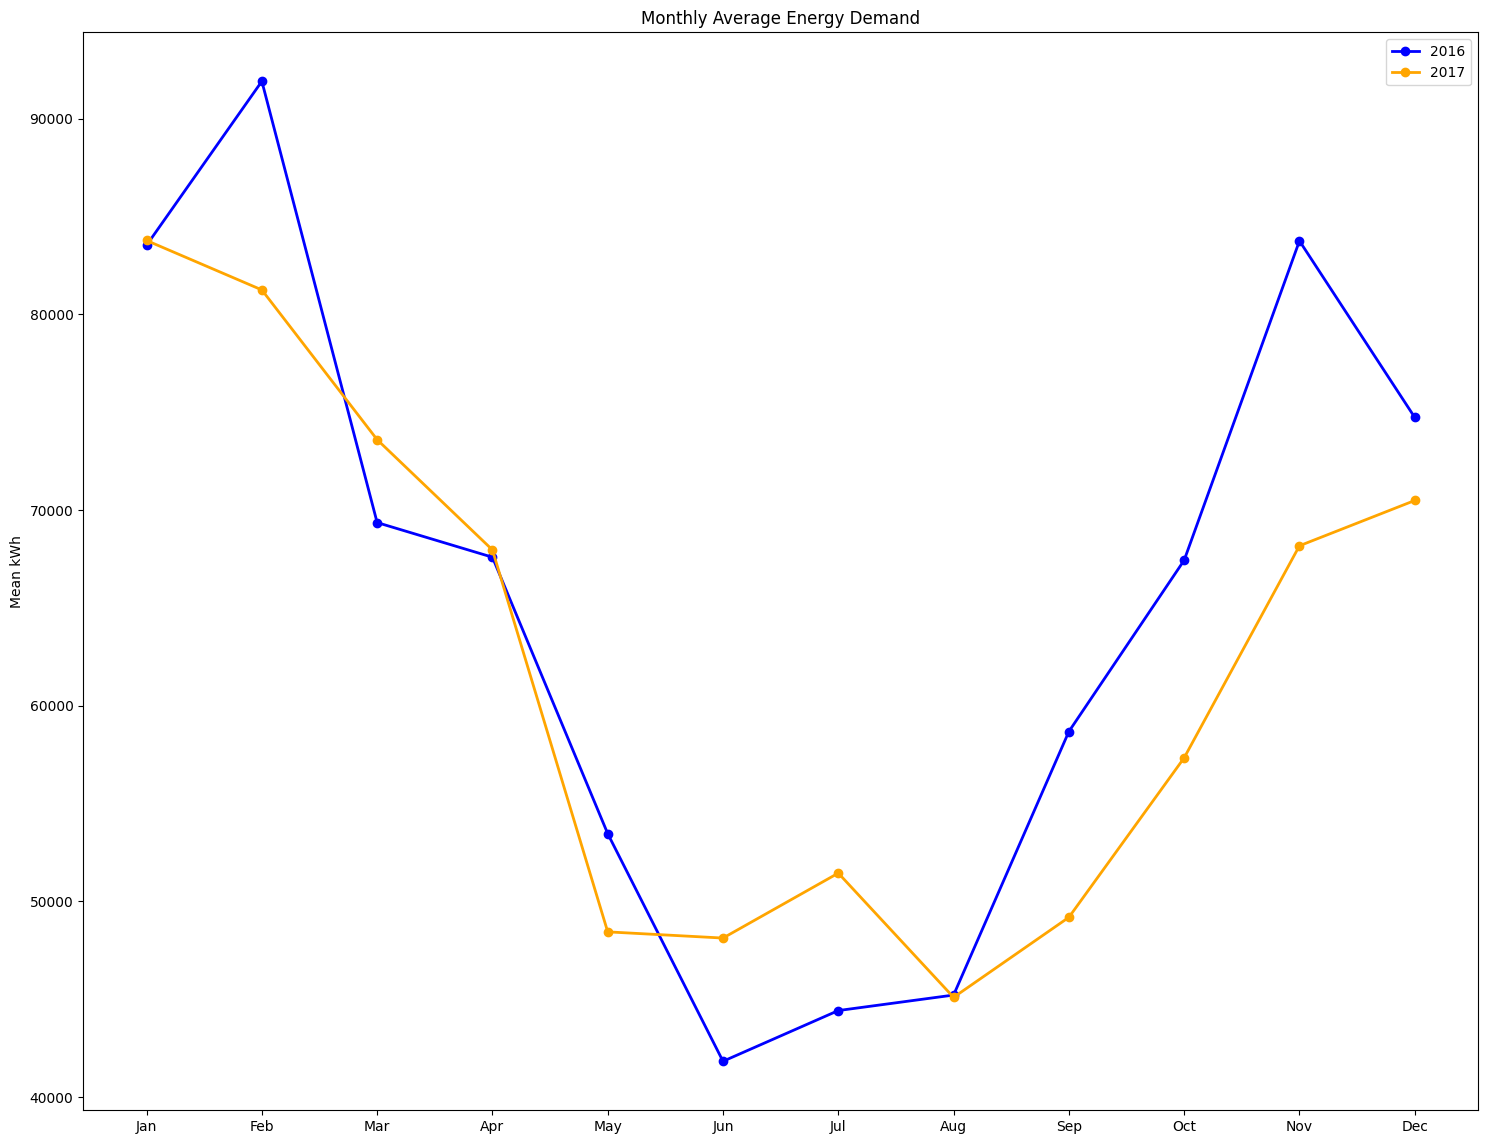

In [24]:
#Figure 3 - Monthly Average Energy Demand
fig3, ax = plt.subplots(figsize=(18,14))  # returns fig and axes

for yr, color in zip([2016, 2017], ["blue", "orange"]):
    monthly = df[df.year==yr].groupby("month")["energy_demand"].mean()
    ax.plot(monthly.index, monthly.values, "o-", color=color, ms=6, lw=2, label=str(yr))

ax.set_xticks(range(1,13))
ax.set_xticklabels(MONTH_NAMES)
ax.set_title("Monthly Average Energy Demand")
ax.set_ylabel("Mean kWh")
ax.legend()
plt.show()
